SAE 2.04
TD4
Equipe 5 : DURAN Kalvin, EAR Francois, EL KANIZI Loubna, ORDAS Ethan, RAOUX Matheo

In [2]:
import os

print("Dossier de travail actuel :")
print(os.getcwd())

print("\nFichiers et dossiers détectés ici :")
print(os.listdir())

Dossier de travail actuel :
/amuhome/e25017332/Exploitation_BD_SAE/SAE2.04-BDD

Fichiers et dossiers détectés ici :
['faker_output_v2', '.ipynb_checkpoints', 'faker_script.py', 'faker_output_v2.zip', 'faker_output_sql.zip', '.git', 'Intention.txt', 'TD4 _Equipe 5 _SAE204.ipynb']


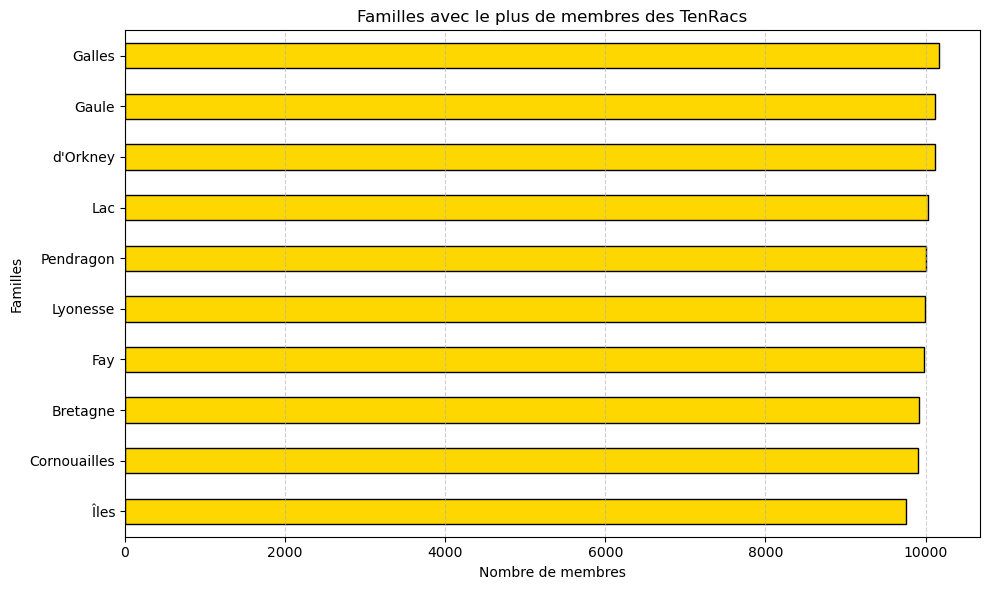

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('faker_output_v3/Membre.csv')

# groupage par famille et on prend les 10 premiers
top_familles = df.groupby(df['nom_membre'].str.split().str[-1]).size().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
top_familles.plot(kind='barh', color='gold', edgecolor='black')

plt.title('Familles avec le plus de membres des TenRacs')
plt.xlabel('Nombre de membres')
plt.ylabel('Familles')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Ce sont les familles qui possède le plus de membres, ici on peut observer que les familles "Galles", "Gaule" et "D'Orkney" possède plus de 10.000 membres. 

In [17]:
import pandas as pd

df = pd.read_csv('faker_output_v3/Membre.csv')

df['famille'] = df['nom_membre'].str.split().str[-1]

effectifs_par_famille = df['famille'].value_counts()

# moyenne des membres par famille
moyenne_membres_famille = effectifs_par_famille.mean()

print(f"En moyenne, chaque famille compte {moyenne_membres_famille:.2f} membres.")

# maximum et minimum 
print(f"Famille avec le plus de membres: {effectifs_par_famille.max()} membres")
print(f"Famille le moins de membres : {effectifs_par_famille.min()} membre(s)")

print("\nFamilles dominantes :")
print(effectifs_par_famille.head(5))

En moyenne, chaque famille compte 10000.00 membres.
Famille avec le plus de membres: 10171 membres
Famille le moins de membres : 9756 membre(s)

Familles dominantes :
famille
Galles       10171
Gaule        10121
d'Orkney     10118
Lac          10036
Pendragon    10010
Name: count, dtype: int64


In [19]:
import pandas as pd

df = pd.read_csv('faker_output_v3/Membre.csv')

# extraction de la ville (dernier mot de l'adresse)
df['famille'] = df['nom_membre'].str.split().str[-1]
effectifs_par_famille = df.groupby('famille').size()

# calcul de l'écart-type
ecart_type_famille = effectifs_par_famille.std()

print(f"Écart-type : {ecart_type_famille:.2f}")
print(f"En calculant le coefficient de variation on trouve 1,22%, on considère donc la répartition homogène.")

Écart-type : 122.79
En calculant le coefficient de variation on trouve 1,22%, on considère donc la répartition homogène.


In [24]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('faker_output_v3/Membre.csv')
df['famille'] = df['nom_membre'].str.split().str[-1]

effectifs = df.groupby('famille').size()

#  25%, 50% (médiane) et 75%
quartiles = effectifs.quantile([0.25, 0.5, 0.75])

print(f" 25% : {quartiles[0.25]}")
print(f"Médiane (50%) : {quartiles[0.50]}")
print(f" 75% : {quartiles[0.75]}")

 25% : 9930.25
Médiane (50%) : 10000.0
 75% : 10097.5


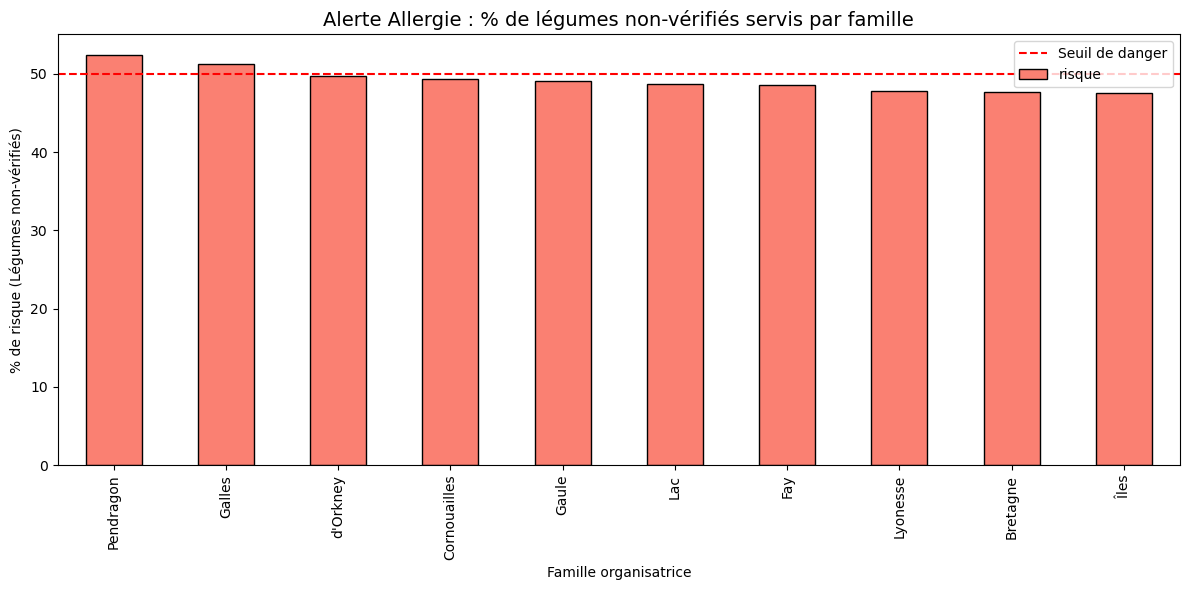

La famille la plus à risque est : Pendragon


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df_repas = pd.read_csv('faker_output_v3/Repas.csv')
df_plat = pd.read_csv('faker_output_v3/plat.csv')
df_legume = pd.read_csv('faker_output_v3/Legume.csv')

df_legume['risque'] = df_legume['verifie'].apply(lambda x: 1 if x == 0 else 0)

# jointure
df_merged = pd.merge(df_repas, df_plat, left_on='IdR', right_on='IdP')
df_merged = pd.merge(df_merged, df_legume, on='IdL')

df_merged['famille'] = df_merged['nom_chevalier_dame'].str.split().str[-1]

# calcul du taux de risque
alerte_allergie = df_merged.groupby('famille')['risque'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 6))
alerte_allergie.plot(kind='bar', color='salmon', edgecolor='black')

plt.title('% de légumes non-vérifiés servis par famille', fontsize=14)
plt.ylabel('% de risque (Légumes non-vérifiés)')
plt.xlabel('Famille organisatrice')
plt.axhline(y=50, color='red', linestyle='--', label='Seuil de danger') # ligne d'alerte 
plt.legend()
plt.tight_layout()
plt.show()


La famille "Pendragon" ou "Galles" sont les familles les plus soumises au risques d'allergie, étant donné le faible écart type auparavant, ce n'est pas une famille en particulier qui est soumise au risques. 

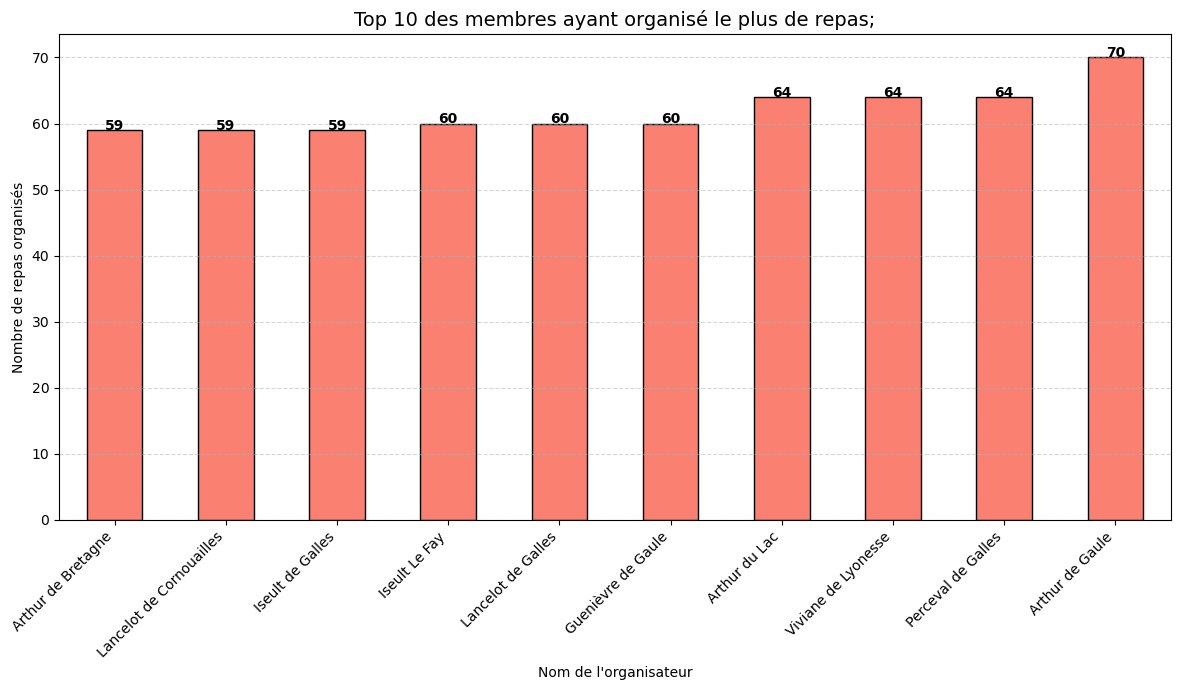

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


repas = pd.read_csv('faker_output_v3/Repas.csv')

# trie par ordre croissant
top_10 = repas['nom_chevalier_dame'].value_counts().head(10).sort_values(ascending=True)

# creation des barres verticale
top_10.plot(kind='bar', color='salmon', edgecolor='black', figsize=(12, 7))

# chiffrage au dessus des barres
for i, v in enumerate(top_10):
    plt.text(i, v + 0.05, str(int(v)), ha='center', fontweight='bold')

plt.title('Top 10 des membres ayant organisé le plus de repas;', fontsize=14)
plt.xlabel('Nom de l\'organisateur')
plt.ylabel('Nombre de repas organisés')

# (inclinaison pour que les noms ne se chevauchent pas)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# evite le debordement
plt.tight_layout()
plt.show()

En faisant le top 10 des membres ayant organisés le plus de repas, on retrouve plusieurs membres de la famille "Gaule" et de la famille "Galles", cela est cohérent avec la statistiques des familles ayant le plus de membres des TenRacs. 